In [1]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

2025-07-16 19:32:36.730260: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752694356.938853      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752694357.001659      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/kaggle/input/melanoma-cancer-dataset/train",
    image_size=(64, 64),
    label_mode='int',
    batch_size = 32,
    validation_split = 0.25,
    subset = "training",
    seed = 42
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/kaggle/input/melanoma-cancer-dataset/train",
    image_size=(64, 64),
    label_mode='int',
    batch_size = 32,
    validation_split = 0.25,
    subset = "validation",
    seed = 42
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/kaggle/input/melanoma-cancer-dataset/test",
    image_size=(64, 64),
    label_mode='int',
    batch_size = 32,
    shuffle = False
)

Found 11879 files belonging to 2 classes.
Using 8910 files for training.


I0000 00:00:1752694381.630342      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 11879 files belonging to 2 classes.
Using 2969 files for validation.
Found 2000 files belonging to 2 classes.


In [3]:
for images, labels in train_ds.take(1):
    single_image = images[0]
    single_label = labels[0]
    print("Single image shape:", single_image.shape)
    print("Label (numeric):", single_label.numpy())

Single image shape: (64, 64, 3)
Label (numeric): 1


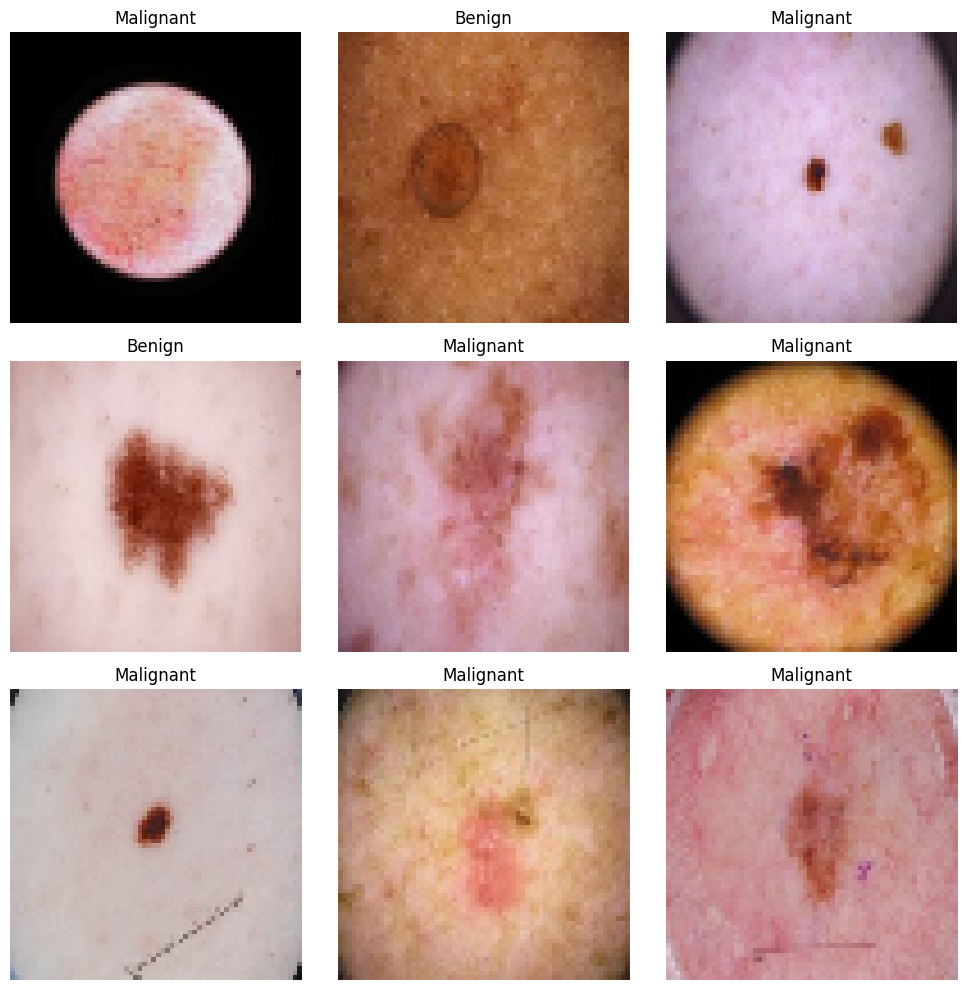

In [4]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_ds))

plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    label = "Benign" if labels[i].numpy() == 0 else "Malignant"
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
for images, labels in train_ds.take(1): 
    print("Images shape:", images.shape) 
    print("Labels shape:", labels.shape) 
    print("Labels:", labels.numpy())      


Images shape: (32, 64, 64, 3)
Labels shape: (32,)
Labels: [1 0 0 0 0 1 0 0 1 1 0 1 0 1 0 1 0 0 1 0 1 1 0 1 1 1 0 0 0 1 0 0]


In [6]:
def normalize(image, label):
    image = tf.cast(image/255., tf.float32)
    return image, label

train_ds = train_ds.map(normalize)
val_ds = val_ds.map(normalize)
test_ds = test_ds.map(normalize)

In [7]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AveragePooling2D, Dense, Dropout, Flatten, BatchNormalization

In [8]:
model = Sequential()
model.add(Conv2D(32, kernel_size = (3, 3), activation = "relu", input_shape=(64, 64, 3), padding="same", kernel_initializer = "he_normal", kernel_regularizer = tf.keras.regularizers.l2(0.001)))
model.add(MaxPooling2D(pool_size = (2, 2), padding="same"))
model.add(Conv2D(64, kernel_size = (3, 3), activation = "relu", padding="same", kernel_initializer = "he_normal", kernel_regularizer = tf.keras.regularizers.l2(0.001)))
model.add(MaxPooling2D(pool_size = (2, 2), padding="same"))
model.add(Conv2D(64, kernel_size = (3, 3), activation = "relu", padding="same", kernel_initializer = "he_normal",  kernel_regularizer = tf.keras.regularizers.l2(0.001)))
model.add(MaxPooling2D(pool_size = (2, 2), padding="same"))
model.add(Conv2D(32, kernel_size = (3, 3), activation = "relu", padding="same", kernel_initializer = "he_normal", kernel_regularizer = tf.keras.regularizers.l2(0.001)))

model.add(Flatten())

model.add(Dense(units = 128, activation = "relu", kernel_initializer = "he_normal", kernel_regularizer = tf.keras.regularizers.l2(0.001)))
model.add(Dropout(0.3))
model.add(Dense(units = 64, activation = "relu", kernel_initializer = "he_normal",  kernel_regularizer = tf.keras.regularizers.l2(0.001)))
model.add(Dropout(0.3))
model.add(Dense(units = 32, activation = "relu",kernel_initializer = "he_normal",  kernel_regularizer = tf.keras.regularizers.l2(0.001)))
model.add(Dropout(0.3))
model.add(Dense(units = 1, kernel_initializer = "glorot_normal", kernel_regularizer = tf.keras.regularizers.l2(0.001), activation = "sigmoid"))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 8, 8, 32)            │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 347,425 (1.33 MB)

 Trainable params: 347,425 (1.33 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
modelCheckpoint = tf.keras.callbacks.ModelCheckpoint(
    "classifier.keras",
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    save_weights_only=False,
    mode='auto',
    save_freq='epoch',
    initial_value_threshold=None
)

In [11]:
model.compile(optimizer = "adam", loss = "binary_crossentropy", metrics = ["accuracy"])

In [12]:
history = model.fit(train_ds, batch_size = 32, epochs = 30, shuffle = True, validation_data = val_ds, callbacks = modelCheckpoint)

Epoch 1/30


I0000 00:00:1752694394.984752      66 service.cc:148] XLA service 0x7bbc48014000 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1752694394.985435      66 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1752694395.516747      66 cuda_dnn.cc:529] Loaded cuDNN version 90300


 12/279 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5021 - loss: 1.5711

I0000 00:00:1752694399.383535      66 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


279/279 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6366 - loss: 1.1769
Epoch 1: val_accuracy improved from -inf to 0.78107, saving model to classifier.keras
279/279 ━━━━━━━━━━━━━━━━━━━━ 24s 55ms/step - accuracy: 0.6368 - loss: 1.1762 - val_accuracy: 0.7811 - val_loss: 0.7977
Epoch 2/30
278/279 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8094 - loss: 0.7112
Epoch 2: val_accuracy improved from 0.78107 to 0.80701, saving model to classifier.keras
279/279 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8095 - loss: 0.7109 - val_accuracy: 0.8070 - val_loss: 0.6697
Epoch 3/30
278/279 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8417 - loss: 0.5867
Epoch 3: val_accuracy improved from 0.80701 to 0.84170, saving model to classifier.keras
279/279 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8418 - loss: 0.5865 - val_accuracy: 0.8417 - val_loss: 0.5486
Epoch 4/30
277/279 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8517 - loss: 0.5270
Epoch 4: val_accuracy improved from 0.84170 

In [13]:
model = tf.keras.models.load_model("classifier.keras")

In [14]:
loss, accuracy = model.evaluate(test_ds)
print(f"Accuracy: {accuracy*100:.2f}%")

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9259 - loss: 0.2852
Accuracy: 91.50%


In [15]:
import matplotlib.pyplot as plt

def plot_metrics(train, val, xlabel, ylabel, title, color):
    plt.plot(train, label = "train", c = color[0], marker = "o")
    plt.plot(val, label = "validation", c = color[1], marker = "o")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()

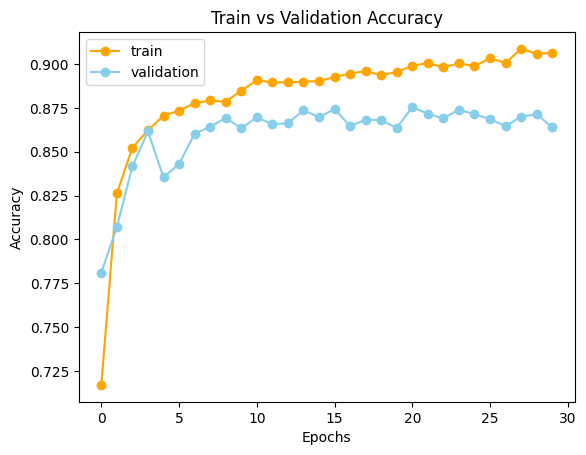

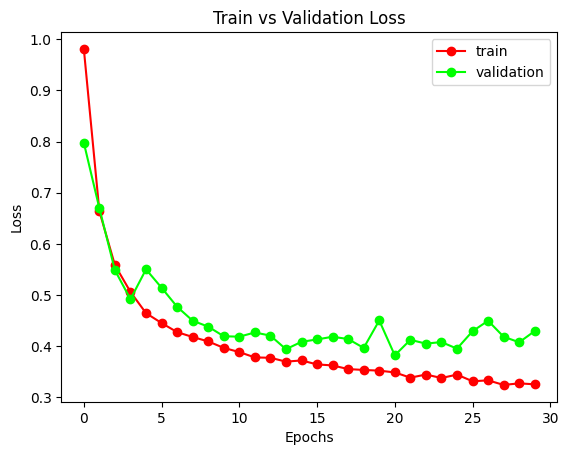

In [16]:
plot_metrics(history.history["accuracy"], history.history["val_accuracy"], "Epochs" , "Accuracy", "Train vs Validation Accuracy", color = ["orange", "skyblue"])
plot_metrics(history.history["loss"], history.history["val_loss"], "Epochs" , "Loss", "Train vs Validation Loss", ["red", "lime"])

In [17]:
import numpy as np

y_pred_probs = model.predict(test_ds) 
y_pred = (y_pred_probs > 0.5).astype(int) 


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [18]:
y_true = []
for _, labels in test_ds:
    y_true.extend(labels.numpy())

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.92      0.92      1000
           1       0.92      0.91      0.91      1000

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.91      2000
weighted avg       0.92      0.92      0.91      2000



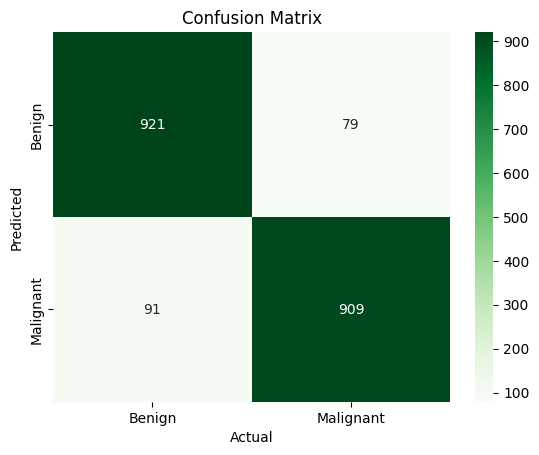

In [20]:
import seaborn as sns
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, cmap = "Greens", annot = True, fmt="d", xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Confusion Matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step


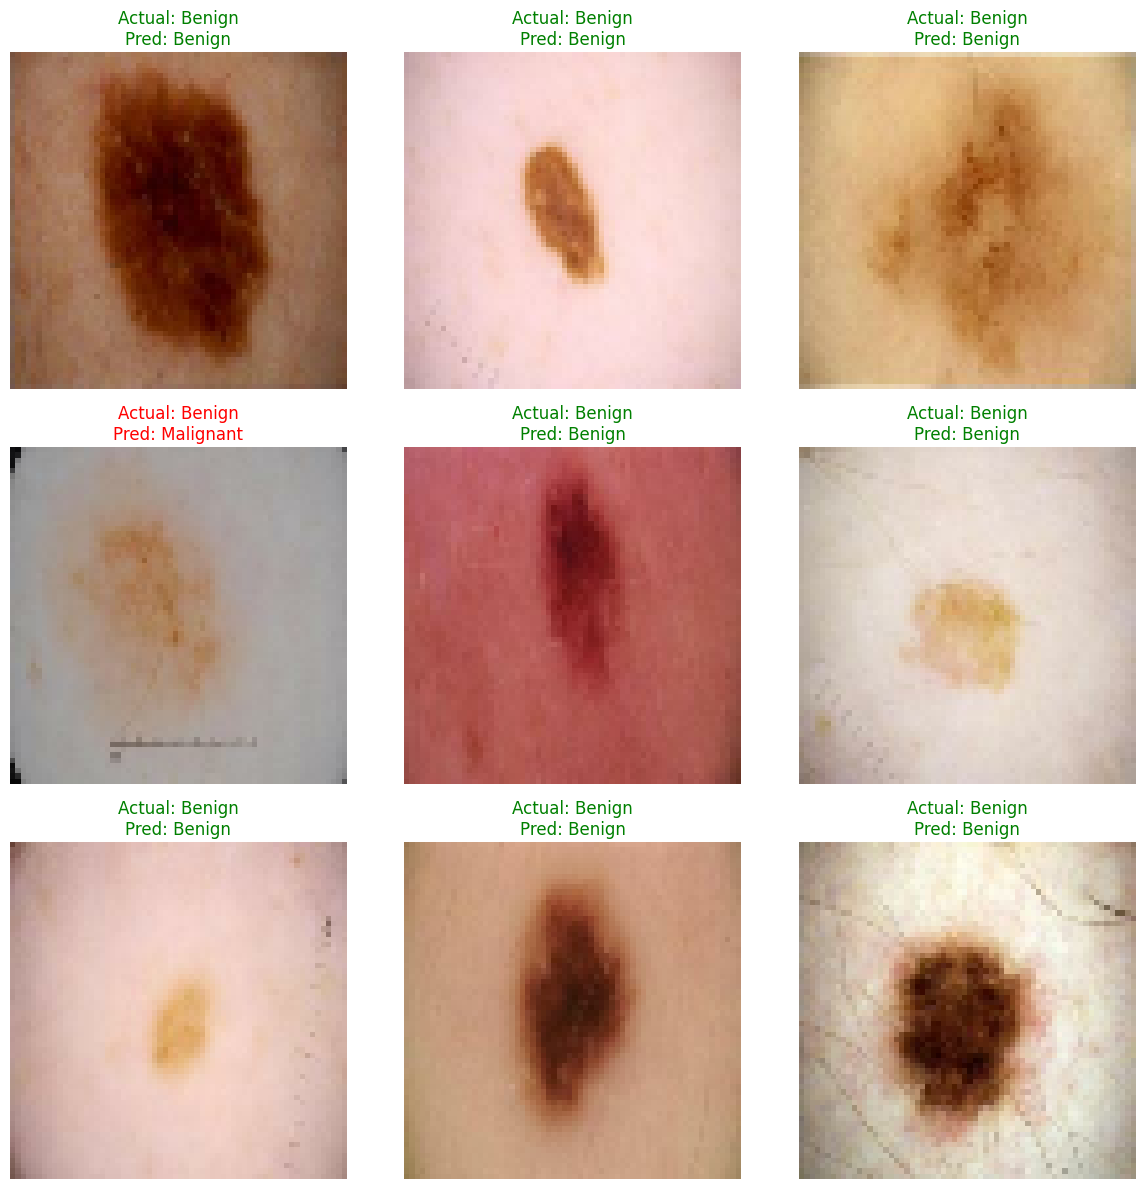

In [21]:
images, labels = next(iter(test_ds))

images_np = (images.numpy()*255).astype("uint8")
labels_np = labels.numpy()

pred_probs = model.predict(images)            
pred_classes = (pred_probs > 0.5).astype("int")  


plt.figure(figsize=(12, 12))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images_np[i])
    
    true_label = "Benign" if labels_np[i] == 0 else "Malignant"
    pred_label = "Benign" if pred_classes[i][0] == 0 else "Malignant"
    
    title_color = "green" if true_label == pred_label else "red"
    plt.title(f"Actual: {true_label}\nPred: {pred_label}", color=title_color)
    plt.axis("off")

plt.tight_layout()
plt.show()